In [ ]:
#1
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import math

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    tf.config.optimizer.set_jit(True)          # XLA JIT fusion


keras.mixed_precision.set_global_policy('mixed_float16')

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {tf.config.list_physical_devices('GPU')}")
print(f"Compute dtype      : {keras.mixed_precision.global_policy().compute_dtype}")

np.random.seed(42)
tf.random.set_seed(42)

LATENT_DIM    = 128
BATCH_SIZE    = 512     # smaller batch -> noiser gradients -> can help for generalisations
LEARNING_RATE = 0.001
WEIGHT_DECAY  = 0.0001
CLIPNORM      = 2.0
EPOCHS        = 150
AES_START_EPOCH = 35
MODEL_START_EPOCH = 30
WARMUP_EPOCHS = 5

BASE_FILTERS  = 16
NUM_LAYERS    = 4
BOTTLENECK_DIM = 4

IMAGE_SIZE_X  = 32
IMAGE_SIZE_Y  = 32
CHANNELS      = 3
STRIDE        = 2

NUM_DOWNSAMP  = int(math.log2(IMAGE_SIZE_X // BOTTLENECK_DIM))

2026-04-24 09:04:17.835294: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-24 09:04:18.565535: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-24 09:04:21.058166: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version : 2.20.0
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Compute dtype      : float16


In [ ]:
#2
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = keras.random.normal(shape=keras.ops.shape(z_mean), dtype=z_mean.dtype)
        return z_mean + keras.ops.exp(0.5 * z_log_var) * epsilon


# ── Encoder ────────────────────────────────────────────────────────────────────
def build_encoder(latent_dim=LATENT_DIM):
    inputs = keras.Input(shape=(IMAGE_SIZE_X, IMAGE_SIZE_Y, CHANNELS))
    x = inputs

    for i in range(NUM_LAYERS):
        filters = BASE_FILTERS * (2 ** i)
        stride  = STRIDE if i < NUM_DOWNSAMP else 1
        x = layers.Conv2D(filters, 3, strides=stride, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)

    x = layers.Flatten()(x)
    x = layers.Dropout(0.2)(x)

    z_mean          = layers.Dense(latent_dim, name='z_mean', dtype='float32')(x)
    # Clamp log-var to [-4, 4]: prevents KL explosion and posterior collapse
    z_log_var_raw   = layers.Dense(latent_dim, name='z_log_var_raw', dtype='float32')(x)
    z_log_var       = layers.Lambda(lambda v: tf.clip_by_value(v, -4.0, 4.0), name='z_log_var')(z_log_var_raw)
    z               = Sampling()([z_mean, z_log_var])

    return keras.Model(inputs, [z_mean, z_log_var, z], name='encoder')


def build_decoder(latent_dim=LATENT_DIM):
    inputs        = keras.Input(shape=(latent_dim,))
    final_filters = BASE_FILTERS * (2 ** (NUM_LAYERS - 1))

    x = layers.Dense(BOTTLENECK_DIM * BOTTLENECK_DIM * final_filters, activation='relu')(inputs)
    x = layers.Reshape((BOTTLENECK_DIM, BOTTLENECK_DIM, final_filters))(x)

    for i in range(NUM_LAYERS - 1, -1, -1):
        filters = BASE_FILTERS * (2 ** i)
        stride  = STRIDE if i < NUM_DOWNSAMP else 1
        x = layers.Conv2DTranspose(filters, 3, strides=stride, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)

    # Final projection back to image space; float32 output regardless of compute dtype
    outputs = layers.Conv2D(CHANNELS, 3, padding='same', activation='tanh', dtype='float32')(x)
    return keras.Model(inputs, outputs, name='decoder')


class VAE(keras.Model):
    def __init__(self, encoder, decoder, kl_weight_var, **kwargs):
        super().__init__(**kwargs)
        self.encoder       = encoder
        self.decoder       = decoder
        self.kl_weight_var = kl_weight_var

        # Keras Mean metrics to automatically populate val_* keys in logs
        self._loss_tracker       = keras.metrics.Mean(name='loss')
        self._recon_loss_tracker = keras.metrics.Mean(name='recon_loss')
        self._kl_loss_tracker    = keras.metrics.Mean(name='kl_loss')

    @property
    def metrics(self):
        return [self._loss_tracker, self._recon_loss_tracker, self._kl_loss_tracker]

    def call(self, x, training=False):
        z_mean, z_log_var, z = self.encoder(x, training=training)
        return self.decoder(z, training=training)

    def _compute_losses(self, x, reconstruction, z_mean, z_log_var):
        x              = tf.cast(x,              tf.float32)
        reconstruction = tf.cast(reconstruction, tf.float32)
        z_mean         = tf.cast(z_mean,         tf.float32)
        z_log_var      = tf.cast(z_log_var,      tf.float32)
        # Reconstruction loss: sum over pixels per sample, mean over batch
        recon_loss = tf.reduce_mean(
            tf.reduce_sum(tf.square(x - reconstruction), axis=[1, 2, 3])
        )
        # KL divergence: sum over latent dims per sample, mean over batch
        # must reduce_sum over axis=1 (latent dim) FIRST, then reduce_mean over batch. 
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1.0 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        )
        total_loss = recon_loss + tf.cast(self.kl_weight_var, tf.float32) * kl_loss
        return total_loss, recon_loss, kl_loss

    def _update_metrics(self, total, recon, kl):
        self._loss_tracker.update_state(total)
        self._recon_loss_tracker.update_state(recon)
        self._kl_loss_tracker.update_state(kl)
        return {
            'loss':       self._loss_tracker.result(),
            'recon_loss': self._recon_loss_tracker.result(),
            'kl_loss':    self._kl_loss_tracker.result(),
        }

    def train_step(self, data):
        x, _ = data
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(x, training=True)
            reconstruction       = self.decoder(z, training=True)
            total, recon, kl     = self._compute_losses(x, reconstruction, z_mean, z_log_var)
        grads = tape.gradient(total, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return self._update_metrics(total, recon, kl)

    def test_step(self, data):
        x, _ = data
        z_mean, z_log_var, z = self.encoder(x, training=False)
        reconstruction       = self.decoder(z, training=False)
        total, recon, kl     = self._compute_losses(x, reconstruction, z_mean, z_log_var)
        return self._update_metrics(total, recon, kl)


kl_weight_var = tf.Variable(0.0, trainable=False, dtype=tf.float32, name='kl_weight')

encoder = build_encoder(latent_dim=LATENT_DIM)
decoder = build_decoder(latent_dim=LATENT_DIM)
vae     = VAE(encoder, decoder, kl_weight_var=kl_weight_var, name='vae')

base_opt = keras.optimizers.AdamW(
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    clipnorm=CLIPNORM,
)

vae.compile(optimizer=base_opt)
print('VAE built successfully')
#encoder.summary()
#decoder.summary()

I0000 00:00:1777017863.024150  469425 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


VAE built successfully


In [ ]:
#3
class AdaptiveEarlyStopping(keras.callbacks.Callback):
    
    def __init__(self, monitor='val_loss', base_patience=12, min_delta=0.01,
                 patience_decay=0.7, min_patience=3, start_epoch=40,
                 restore_best_weights=True, verbose=True):
        super().__init__()
        self.monitor              = monitor
        self.base_patience        = base_patience
        self.current_patience     = base_patience
        self.min_delta            = min_delta
        self.patience_decay       = patience_decay
        self.min_patience         = min_patience
        self.start_epoch          = start_epoch
        self.restore_best_weights = restore_best_weights
        self.verbose              = verbose

        self.best                 = np.inf
        self.wait                 = 0
        self.best_weights         = None
        self._prev_lr             = None
        self.stopped_epoch        = 0

    def on_train_begin(self, logs=None):
        self.best               = np.inf
        self.wait               = 0
        self.best_weights       = None
        self._prev_lr           = float(keras.backend.get_value(self.model.optimizer.learning_rate))
        self.current_patience   = self.base_patience

    def on_epoch_end(self, epoch, logs=None):
        if epoch < self.start_epoch:
            return      # silent
        
        logs    = logs or {}
        current = logs.get(self.monitor)
        if current is None:
            return

        # Detect LR reduction (e.g. from a separate LR-scheduler callback)
        current_lr = float(keras.backend.get_value(self.model.optimizer.learning_rate))

        # Only count as a meaningful LR drop if it fell by more than 10% relative, ignores the tiny per-step decreases from cosine decay, while still catching hard step-drops from ReduceLROnPlateau
        if self._prev_lr is not None:
            relative_drop = (self._prev_lr - current_lr) / (self._prev_lr + 1e-10)
            if relative_drop > 0.10:
                self.current_patience = max(
                    self.min_patience,
                    int(self.current_patience * self.patience_decay)
                )
                if self.verbose:
                    print(f'\n[AdaptiveES] LR dropped {self._prev_lr:.2e} → {current_lr:.2e}; '
                          f'({relative_drop*100:.1f}%); patience → {self.current_patience}')
        self._prev_lr = current_lr

        if current < self.best - self.min_delta:
            self.best         = current
            self.wait         = 0
            self.best_weights = self.model.get_weights()
        else:
            self.wait += 1
            if self.verbose:
                print(f'\n[AdaptiveES] No improvement for {self.wait}/{self.current_patience} epochs '
                      f'epochs (best={self.best:.4f})')
            if self.wait >= self.current_patience:
                self.stopped_epoch       = epoch
                self.model.stop_training = True
                if self.restore_best_weights and self.best_weights is not None:
                    if self.verbose:
                        print('\n[AdaptiveES] Restoring best weights.')
                    self.model.set_weights(self.best_weights)
        
        print(f'\n(Learning Rate = {current_lr:.2e})')

    def on_train_end(self, logs=None):
        if self.stopped_epoch > 0 and self.verbose:
            print(f'\n[AdaptiveES] Training stopped at epoch {self.stopped_epoch + 1}.')


class DelayedModelCheckpoint(keras.callbacks.ModelCheckpoint):
    """Skips saving entirely before `start_epoch`."""
    def __init__(self, *args, start_epoch=20, **kwargs):
        super().__init__(*args, **kwargs)
        self.start_epoch = start_epoch

    def on_epoch_end(self, epoch, logs=None):
        if epoch < self.start_epoch:
            return
        super().on_epoch_end(epoch, logs)

In [ ]:
#4
(x_train, _), (x_test, _) = keras.datasets.cifar10.load_data()

x_train = (x_train.astype('float32') / 127.5) - 1.0
x_test  = (x_test.astype('float32')  / 127.5) - 1.0

print(f'Training data : {x_train.shape}')
print(f'Test data     : {x_test.shape}')


@tf.function
def augment(x, y):
    x = tf.image.random_flip_left_right(x)
    x = tf.image.random_brightness(x, max_delta=0.1)   # adds richer variety to training images
    x = tf.image.random_contrast(x, lower=0.9, upper=1.1)
    x = tf.clip_by_value(x, -1.0, 1.0)                # keep values in valid [-1, 1] range after augmentation
    return x, x   # VAE targets == inputs


# .cache() keeps the dataset in RAM after first epoch (CIFAR-10 ≈ 600 MB, fits easily)
# Full-dataset shuffle buffer gives proper iid batches.
train_dataset = (
    tf.data.Dataset.from_tensor_slices((x_train, x_train))
    .cache()
    .shuffle(len(x_train))          # full dataset shuffle
    .batch(BATCH_SIZE)
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    tf.data.Dataset.from_tensor_slices((x_test, x_test))
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

total_steps  = (len(x_train) // BATCH_SIZE) * EPOCHS
warmup_steps = (len(x_train) // BATCH_SIZE) * WARMUP_EPOCHS

lr_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=LEARNING_RATE,
    decay_steps=total_steps - warmup_steps,
    alpha=1e-6,          # minimum LR at end of cosine decay
    warmup_target=LEARNING_RATE,
    warmup_steps=warmup_steps,
)

# Re-compile with scheduled LR
base_opt_scheduled = keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    weight_decay=WEIGHT_DECAY,
    clipnorm=CLIPNORM,
)
vae.compile(optimizer=base_opt_scheduled)

# Force-build the model so ModelCheckpoint can save it
dummy = tf.zeros((1, IMAGE_SIZE_X, IMAGE_SIZE_Y, CHANNELS))
vae(dummy, training=False)
print('Model built — ready to train.')


adaptive_es = AdaptiveEarlyStopping(
    monitor='val_loss',
    base_patience=12,
    min_delta=0.01,
    patience_decay=0.5,
    start_epoch=AES_START_EPOCH,
    restore_best_weights=True,
    verbose=True,
)

checkpoint = DelayedModelCheckpoint(
    'vae_best.weights.h5',
    start_epoch=MODEL_START_EPOCH,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    verbose=1,
)

csv_logger = keras.callbacks.CSVLogger('training_log.csv', append=False)

history = vae.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    callbacks=[kl_annealing, adaptive_es, checkpoint, csv_logger],
)

/tmp/ipykernel_469425/430226738.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


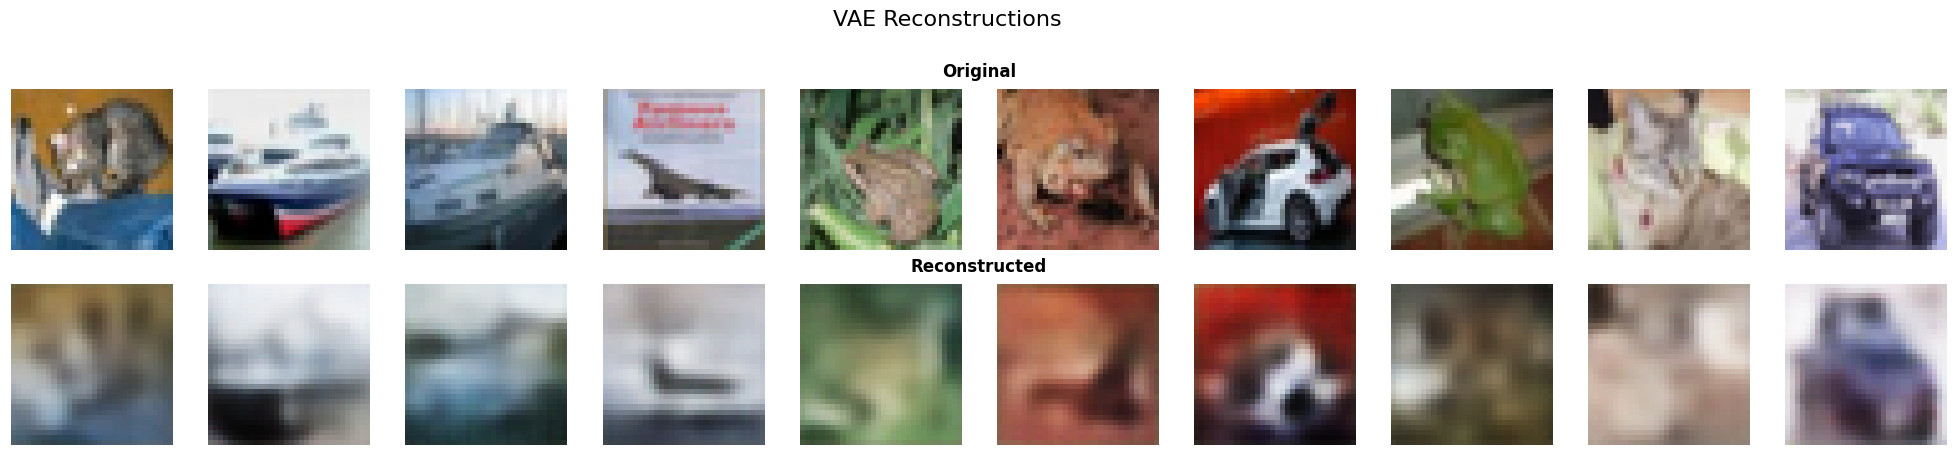

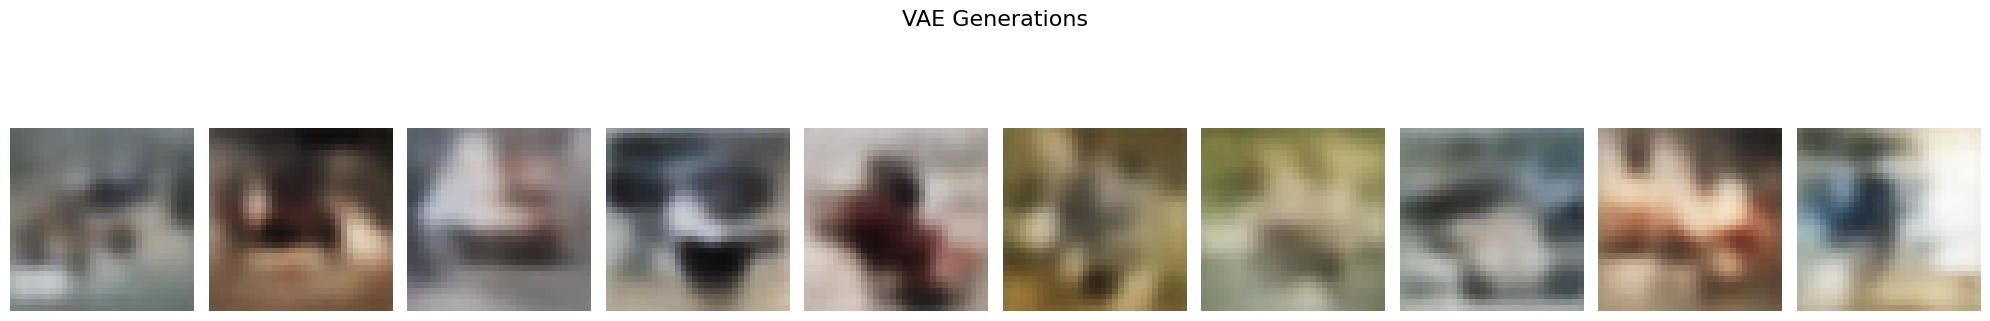

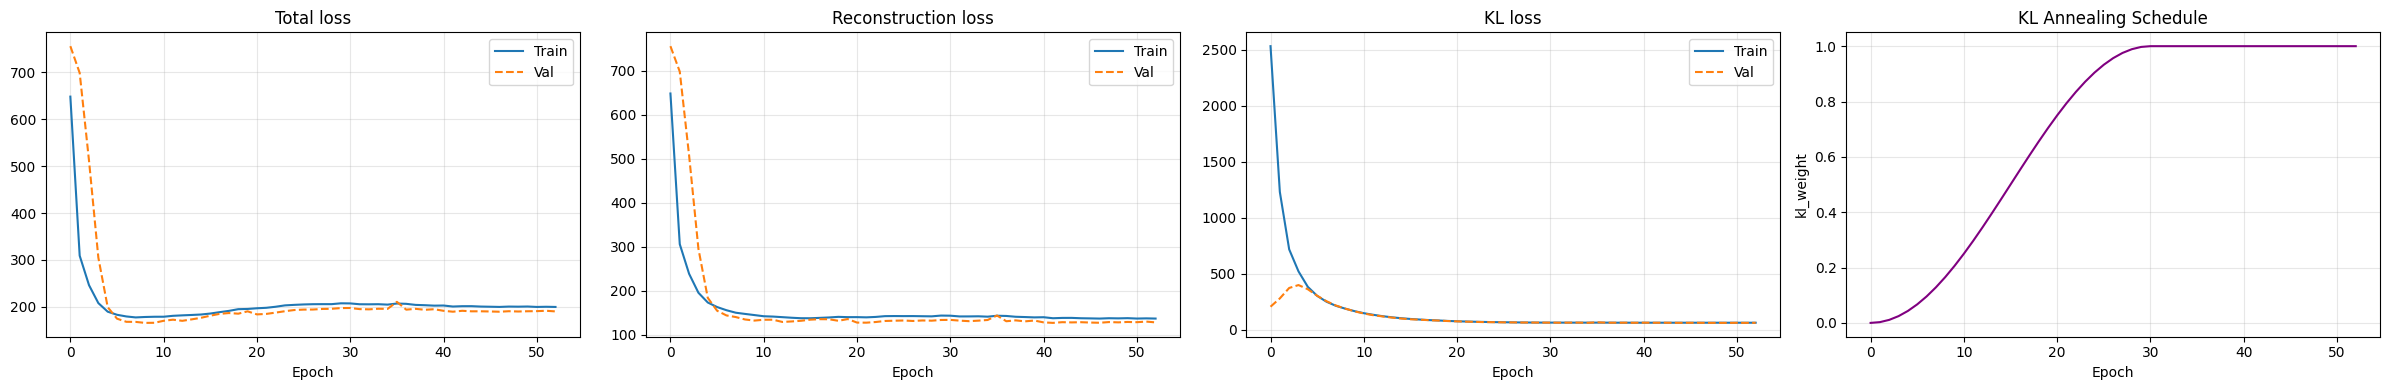

Final train loss : 199.9155
Final val loss   : 190.4096
Final recon loss : 136.7729
Final KL loss    : 63.1426


In [ ]:
#5
def tanh_display(img):
    """Map [-1, 1] → [0, 1] for imshow."""
    return (np.clip(img, -1.0, 1.0) + 1.0) / 2.0


test_samples  = x_test[:10]
reconstructed = vae.predict(test_samples, verbose=0)

fig = plt.figure(figsize=(25, 5))
gs  = fig.add_gridspec(4, 10, height_ratios=[0.15, 1, 0.15, 1], hspace=0.05)

for label, row in [('Original', 0), ('Reconstructed', 2)]:
    ax = fig.add_subplot(gs[row, :])
    ax.text(0.5, 0.5, label, ha='center', va='center', fontsize=12, fontweight='bold')
    ax.axis('off')

for i in range(10):
    ax = fig.add_subplot(gs[1, i])
    ax.imshow(tanh_display(test_samples[i]))
    ax.axis('off')
    ax = fig.add_subplot(gs[3, i])
    ax.imshow(tanh_display(reconstructed[i]))
    ax.axis('off')

plt.suptitle('VAE Reconstructions', fontsize=16)
plt.tight_layout()
plt.show()


random_latent = np.random.normal(size=(10, LATENT_DIM))
generated     = decoder.predict(random_latent, verbose=0)

fig, axes = plt.subplots(1, 10, figsize=(20, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(tanh_display(generated[i]))
    ax.axis('off')
plt.suptitle('VAE Generations', fontsize=16)
plt.tight_layout()
plt.show()


hist    = history.history
n_plots = 4 if 'kl_weight' in hist else 3

fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 4))

panels = [
    ('Total loss',          'loss',       'val_loss'),
    ('Reconstruction loss', 'recon_loss', 'val_recon_loss'),
    ('KL loss',             'kl_loss',    'val_kl_loss'),
]

for ax, (title, train_key, val_key) in zip(axes, panels):
    if train_key in hist:
        ax.plot(hist[train_key], label='Train')
    if val_key in hist:
        ax.plot(hist[val_key], label='Val', linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

if 'kl_weight' in hist:
    ax = axes[-1]
    ax.plot(hist['kl_weight'], color='purple')
    ax.set_title('KL Annealing Schedule')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('kl_weight')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final train loss : {hist['loss'][-1]:.4f}")
print(f"Final val loss   : {hist['val_loss'][-1]:.4f}")
if 'recon_loss' in hist:
    print(f"Final recon loss : {hist['recon_loss'][-1]:.4f}")
if 'kl_loss' in hist:
    print(f"Final KL loss    : {hist['kl_loss'][-1]:.4f}")

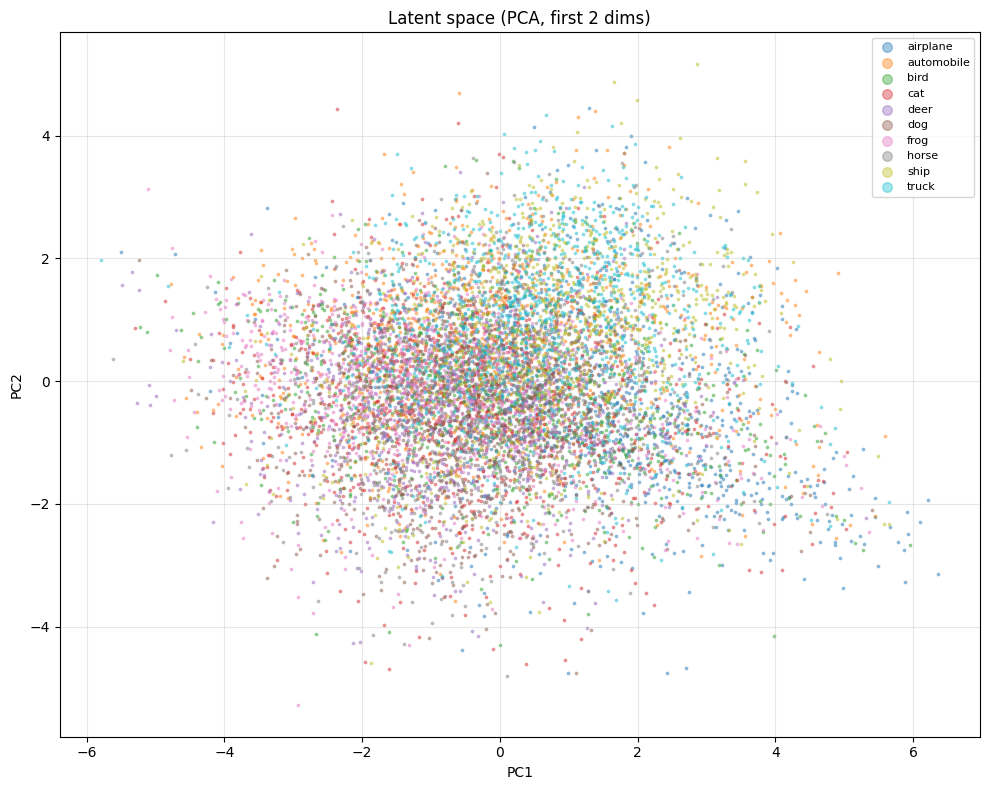

Model: "vae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Functional)            │ ((None, 128), (None,   │       622,944 │
│                                 │ 128), (None, 128))     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ input_layer (InputLayer)   │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2d (Conv2D)            │ (None, 16, 16, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ batch_normalization        │ (None, 16, 16, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2d_1 (Conv2D)          │ (None, 8, 8, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ batch_normalization_1      │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2d_2 (Conv2D)          │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ batch_normalization_2      │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2d_3 (Conv2D)          │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ batch_normalization_3      │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ flatten (Flatten)          │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dropout (Dropout)          │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ z_log_var_raw (Dense)      │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ z_mean (Dense)             │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ z_log_var (Lambda)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ sampling (Sampling)        │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 32, 32, 3)      │       510,051 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ input_layer_1 (InputLayer) │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dense (Dense)              │ (None, 2048)           │       264,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ reshape (Reshape)          │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2d_transpose           │ (None, 4, 4, 128)      │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ batch_normalization_4      │ (None, 4, 4, 128)      │           51

 Total params: 3,397,070 (12.96 MB)

 Trainable params: 1,132,035 (4.32 MB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 2,264,075 (8.64 MB)

In [ ]:
#6
(_, y_test_labels) = keras.datasets.cifar10.load_data()[1]

z_means, _, _ = encoder.predict(x_test, verbose=0)

# Manual PCA using NumPy — no sklearn needed
z_centred            = z_means - z_means.mean(axis=0)
cov                  = np.cov(z_centred, rowvar=False)
eigenvals, eigenvecs = np.linalg.eigh(cov)
# eigh returns ascending order — take the last 2 (largest variance)
top2                 = eigenvecs[:, -2:][:, ::-1]
z_2d                 = z_centred @ top2

labels = y_test_labels.flatten()

cifar10_classes = ['airplane','automobile','bird','cat','deer',
                   'dog','frog','horse','ship','truck']

plt.figure(figsize=(10, 8))
for cls in range(10):
    mask = labels == cls
    plt.scatter(z_2d[mask, 0], z_2d[mask, 1], s=3, alpha=0.4, label=cifar10_classes[cls])

plt.title('Latent space (PCA, first 2 dims)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(markerscale=4, loc='best', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

vae.summary(expand_nested=True)